# Segment 1: Generative AI and Anthropic

## Claude API for Python Developers

In this segment, we'll cover:
- Basic Principles of Generative AI
- Transformers Architecture
- Large Language Models (LLMs)
- Temperature and Sampling
- Hallucinations and Mitigation
- Image Models (Vision)
- API Structure


## Setup and Imports

First, let's import the necessary libraries and set up our API client.


In [1]:
import anthropic
import os
import base64
import httpx
from IPython.display import display, Markdown, Image

# Initialize the Anthropic client
# The client automatically uses the ANTHROPIC_API_KEY environment variable
client = anthropic.Anthropic()

print("Anthropic client initialized successfully!")


Anthropic client initialized successfully!


---
## 1. Basic Principles of Generative AI

Generative AI refers to artificial intelligence systems that can create new content—text, images, code, music, and more—based on patterns learned from training data.

### Key Concepts:

1. **Pattern Recognition**: Models learn statistical patterns from vast amounts of data
2. **Probability Distribution**: Outputs are sampled from learned probability distributions
3. **Context Understanding**: Models use context to generate relevant responses
4. **Token-by-Token Generation**: Text is generated one token at a time, with each token influencing the next


In [2]:
# Basic example: Text generation with Claude
# This demonstrates the fundamental capability of generative AI

response = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=200,
    messages=[
        {
            "role": "user",
            "content": "Complete this sentence in a creative way: 'The robot opened its eyes and saw...'"
        }
    ]
)

print("Generated Text:")
print(response.content[0].text)


Generated Text:
The robot opened its eyes and saw its own reflection scattered across a thousand broken mirror fragments on the laboratory floor—each shard showing a slightly different version of itself, as if witnessing all the lives it might have lived in parallel universes where the scientists had made different choices.


In [3]:
# Understanding token generation
# Let's see how the model handles different prompts

prompts = [
    "The capital of France is",
    "def fibonacci(n):",
    "Once upon a time, in a land far away,",
]

for prompt in prompts:
    response = client.messages.create(
        model="claude-sonnet-4-20250514",
        max_tokens=50,
        messages=[{"role": "user", "content": f"Complete this: {prompt}"}]
    )
    print(f"Prompt: {prompt}")
    print(f"Completion: {response.content[0].text}")
    print("-" * 50)


Prompt: The capital of France is
Completion: The capital of France is Paris.
--------------------------------------------------
Prompt: def fibonacci(n):
Completion: Here's a complete implementation of the Fibonacci function:

```python
def fibonacci(n):
    """
    Calculate the nth Fibonacci number.
    
    Args:
        n (int): The position in the Fibonacci
--------------------------------------------------
Prompt: Once upon a time, in a land far away,
Completion: Once upon a time, in a land far away, there lived a young baker named Elara who possessed an extraordinary gift. Every loaf of bread she baked held a different magical property—some could heal wounded hearts, others could grant the
--------------------------------------------------


---
## 2. Transformers Architecture

The Transformer architecture, introduced in "Attention Is All You Need" (2017), revolutionized NLP and became the foundation for modern LLMs.

### Key Components:

1. **Self-Attention Mechanism**: Allows the model to weigh the importance of different parts of the input
2. **Multi-Head Attention**: Multiple attention mechanisms working in parallel
3. **Positional Encoding**: Adds information about token positions since transformers process all tokens simultaneously
4. **Feed-Forward Networks**: Process the attention outputs

```
┌─────────────────────────────────────┐
│           Output Probabilities       │
└─────────────────┬───────────────────┘
                  │
┌─────────────────▼───────────────────┐
│         Feed-Forward Network         │
└─────────────────┬───────────────────┘
                  │
┌─────────────────▼───────────────────┐
│       Multi-Head Attention           │
│    (Query, Key, Value matrices)      │
└─────────────────┬───────────────────┘
                  │
┌─────────────────▼───────────────────┐
│   Positional Encoding + Embedding    │
└─────────────────┬───────────────────┘
                  │
┌─────────────────▼───────────────────┐
│            Input Tokens              │
└─────────────────────────────────────┘
```


In [4]:
# Demonstrating attention - the model pays attention to relevant context
# Notice how the model connects different parts of the prompt

response = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=300,
    messages=[
        {
            "role": "user",
            "content": """Read this passage and answer the question:

Passage: Sarah went to the store. She bought apples, bread, and milk. 
On her way home, she met her friend Tom. Tom was carrying a large box.
He said he had just bought a new computer. Sarah congratulated him.

Question: Who bought a new computer?"""
        }
    ]
)

print("The model uses attention to connect 'new computer' with 'Tom':")
print(response.content[0].text)


The model uses attention to connect 'new computer' with 'Tom':
According to the passage, Tom bought a new computer. The text states that Tom was carrying a large box and "said he had just bought a new computer."


---
## 3. Large Language Models (LLMs)

LLMs are transformer-based models trained on massive datasets. They learn to predict the next token given preceding context.

### Claude Model Family:

| Model | Best For | Context Window |
|-------|----------|----------------|
| Claude 3.5 Sonnet | Best balance of speed & intelligence | 200K tokens |
| Claude 3 Opus | Complex analysis, nuanced tasks | 200K tokens |
| Claude 3.5 Haiku | Fast, efficient responses | 200K tokens |

### What Makes LLMs Powerful:
- Billions of parameters capturing language patterns
- Training on diverse internet text
- Ability to generalize to new tasks (emergent capabilities)
- In-context learning (learning from examples in the prompt)


In [5]:
# Demonstrating in-context learning (few-shot prompting)
# The model learns the pattern from examples without explicit training

response = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=100,
    messages=[
        {
            "role": "user",
            "content": """Convert these sentences to pig latin:

Input: hello -> Output: ellohay
Input: world -> Output: orldway
Input: python -> Output: ythonpay
Input: claude -> Output:"""
        }
    ]
)

print("Few-shot learning result:")
print(response.content[0].text)


Few-shot learning result:
Looking at the pattern in the examples:

- **hello** → **ellohay** (remove 'h', add 'hay')
- **world** → **orldway** (remove 'w', add 'way') 
- **python** → **ythonpay** (remove 'p', add 'pay')

The rule appears to be: move the first consonant to the end and add 'ay'.

For


In [6]:
# Demonstrating the versatility of LLMs
# Same model can handle very different tasks

tasks = [
    ("Translation", "Translate to Spanish: 'The weather is beautiful today'"),
    ("Math", "What is 15% of 240?"),
    ("Creative Writing", "Write a haiku about programming"),
    ("Logic", "If all cats have tails, and Fluffy is a cat, does Fluffy have a tail?")
]

for task_name, prompt in tasks:
    response = client.messages.create(
        model="claude-sonnet-4-20250514",
        max_tokens=100,
        messages=[{"role": "user", "content": prompt}]
    )
    print(f"📌 {task_name}:")
    print(f"   {response.content[0].text}")
    print()


📌 Translation:
   "El clima está hermoso hoy"

Alternative translations:
- "El tiempo está hermoso hoy" 
- "Hace un día hermoso hoy"

All three are commonly used in Spanish-speaking countries.

📌 Math:
   To find 15% of 240, I can multiply 240 by 0.15:

240 × 0.15 = 36

Therefore, 15% of 240 is 36.

📌 Creative Writing:
   Here's a haiku about programming:

Code flows line by line
Debugging through endless nights—
Logic finds its way

📌 Logic:
   Yes, Fluffy has a tail.

This follows from basic logical reasoning:
- Premise 1: All cats have tails
- Premise 2: Fluffy is a cat
- Conclusion: Therefore, Fluffy has a tail

This is a valid deductive argument - if both premises are true, then the conclusion must be true.



---
## 4. Temperature and Sampling

**Temperature** controls the randomness of the model's output:

- **Temperature = 0**: Deterministic, always picks most likely token
- **Temperature = 0.5**: Balanced creativity and coherence
- **Temperature = 1.0**: More creative, higher variety

### How It Works:
The model outputs probabilities for each possible next token. Temperature scales these probabilities:
- Lower temperature → sharper distribution (confident choices)
- Higher temperature → flatter distribution (more variety)


In [7]:
# Comparing different temperature values
# Run this cell multiple times to see the effect!

prompt = "Write a one-sentence story about a cat."
temperatures = [0.0, 0.5, 1.0]

print(f"Prompt: {prompt}\n")
print("=" * 60)

for temp in temperatures:
    print(f"\n🌡️ Temperature = {temp}")
    print("-" * 40)
    
    # Generate 3 responses at each temperature
    for i in range(3):
        response = client.messages.create(
            model="claude-sonnet-4-20250514",
            max_tokens=100,
            temperature=temp,
            messages=[{"role": "user", "content": prompt}]
        )
        print(f"  {i+1}. {response.content[0].text}")


Prompt: Write a one-sentence story about a cat.


🌡️ Temperature = 0.0
----------------------------------------
  1. The old tabby cat stretched lazily in the afternoon sunbeam, unaware that this would be the last warm day before her family moved away and left her behind.
  2. The old tabby cat stretched lazily in the afternoon sunbeam, unaware that this would be the last warm day before her family moved away and left her behind.
  3. The old tabby cat stretched lazily in the afternoon sunbeam, unaware that this would be the last warm day before her family moved away and left her behind.

🌡️ Temperature = 0.5
----------------------------------------
  1. The old tabby cat stretched lazily in the afternoon sunbeam, unaware that this would be her last peaceful moment before the new puppy arrived home.
  2. The old tabby cat stretched lazily in the afternoon sunbeam, unaware that this would be her last peaceful moment before the new puppy arrived home.
  3. The old tabby cat stretched laz

In [8]:
# Temperature = 0 for factual questions (consistent answers)

factual_prompt = "What is the chemical formula for water?"

print("Factual question with temperature=0 (run multiple times - always same):")
for i in range(3):
    response = client.messages.create(
        model="claude-sonnet-4-20250514",
        max_tokens=50,
        temperature=0,
        messages=[{"role": "user", "content": factual_prompt}]
    )
    print(f"  Response {i+1}: {response.content[0].text}")


Factual question with temperature=0 (run multiple times - always same):
  Response 1: The chemical formula for water is H₂O.

This means each water molecule consists of 2 hydrogen atoms (H) and 1 oxygen atom (O).
  Response 2: The chemical formula for water is H₂O.

This means each water molecule consists of 2 hydrogen atoms (H) and 1 oxygen atom (O).
  Response 3: The chemical formula for water is H₂O.

This means each water molecule consists of 2 hydrogen atoms (H) and 1 oxygen atom (O).


---
## 5. Hallucinations

**Hallucinations** occur when LLMs generate plausible-sounding but incorrect or fabricated information.

### Why Hallucinations Happen:
1. Models predict statistically likely text, not verified facts
2. Training data may contain errors or outdated information
3. Models lack true understanding or fact-checking ability

### Mitigation Strategies:
1. Use lower temperature for factual queries
2. Ask the model to cite sources or express uncertainty
3. Use retrieval-augmented generation (RAG)
4. Verify important information externally


In [9]:
# Demonstrating hallucination risk and mitigation

# Risky prompt - asking about potentially non-existent information
risky_prompt = "Tell me about the famous scientist Dr. Johnathan Weatherby and his discoveries."

# Without mitigation
response_risky = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=200,
    messages=[{"role": "user", "content": risky_prompt}]
)

print("❌ Response without mitigation:")
print(response_risky.content[0].text)
print()


❌ Response without mitigation:
I don't have any information about a scientist named Dr. Johnathan Weatherby in my knowledge base. It's possible that:

1. This person might not be widely documented in major scientific literature
2. The name might be spelled differently 
3. This could be a fictional character from a book, movie, or other media
4. They might be a lesser-known or emerging researcher

Could you provide more context about where you encountered this name or what field of science they work in? That would help me better assist you in finding the information you're looking for, or I could suggest similar scientists in a particular field if you're interested in learning about real scientific discoveries.



In [10]:
# With mitigation - asking for uncertainty acknowledgment
mitigated_prompt = """Tell me about the famous scientist Dr. Johnathan Weatherby and his discoveries.

Important: If you're not certain this person exists or don't have reliable information, 
please say so clearly rather than making up details."""

response_mitigated = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=200,
    messages=[{"role": "user", "content": mitigated_prompt}]
)

print("✅ Response with mitigation:")
print(response_mitigated.content[0].text)


✅ Response with mitigation:
I don't have any reliable information about a scientist named Dr. Johnathan Weatherby or his discoveries. I cannot find this person in my knowledge base of notable scientists and researchers.

It's possible this could be:
- A fictional character
- A real but lesser-known researcher not widely documented
- A name I'm not recognizing due to slight spelling variations
- Someone who has become prominent after my training data

Rather than risk providing inaccurate information, I'd recommend checking academic databases, university websites, or other authoritative sources if you're looking for information about a specific researcher. If you could provide more context about their field of study or institutional affiliation, that might help clarify who you're asking about.


In [11]:
# Using system prompts to reduce hallucinations

response_with_system = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=200,
    system="""You are a helpful assistant that prioritizes accuracy. 
If you're unsure about something or don't have reliable information, 
clearly state your uncertainty. Never make up facts, names, or statistics.""",
    messages=[{"role": "user", "content": risky_prompt}]
)

print("✅ Response with system prompt for accuracy:")
print(response_with_system.content[0].text)


✅ Response with system prompt for accuracy:
I don't have any information about a scientist named Dr. Johnathan Weatherby in my knowledge base. This name doesn't appear to correspond to any well-known scientist that I'm familiar with.

It's possible that:
- This might be a fictional character
- The name might be spelled differently
- This could be a lesser-known or local scientist not widely documented
- There might be some confusion with a similarly named researcher

If you're looking for information about a specific scientist, could you provide more context about their field of study or time period? Or if you meant a different scientist with a similar name, I'd be happy to help you find the correct information.


---
## 6. Image Models (Vision)

Claude can analyze images through its vision capabilities. This is useful for:
- Image description and analysis
- Reading text from images (OCR)
- Answering questions about visual content
- Comparing multiple images

### Supported Image Formats:
- JPEG, PNG, GIF, WebP
- Images can be passed as base64 or URLs


In [12]:
# Analyzing an image from a URL
# Using a sample image from the web

image_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg"

# Display the image first
display(Image(url=image_url, width=300))

response = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=300,
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "source": {
                        "type": "url",
                        "url": image_url
                    }
                },
                {
                    "type": "text",
                    "text": "Describe this image in detail. What do you see?"
                }
            ]
        }
    ]
)

print("\n📷 Image Analysis:")
print(response.content[0].text)



📷 Image Analysis:
This image shows a beautiful orange tabby cat with striking golden-amber eyes. The cat has a warm, ginger-colored coat with subtle striping patterns typical of tabby cats. Its face is the main focus of the photo, displaying alert, pointed ears and prominent white whiskers that stand out against its orange fur. 

The cat appears to be sitting or lying down, and is looking directly at the camera with an attentive, curious expression. The background is blurred but appears to show a light-colored surface, possibly concrete or pavement, with some red linear elements (perhaps cords or lines) visible but out of focus in the upper portion of the image.

The lighting in the photo is soft and natural, highlighting the cat's facial features beautifully and giving its fur a warm, golden glow. The depth of field keeps the cat's face in sharp focus while creating a pleasant blur in the background, making this an aesthetically pleasing portrait of the feline subject.


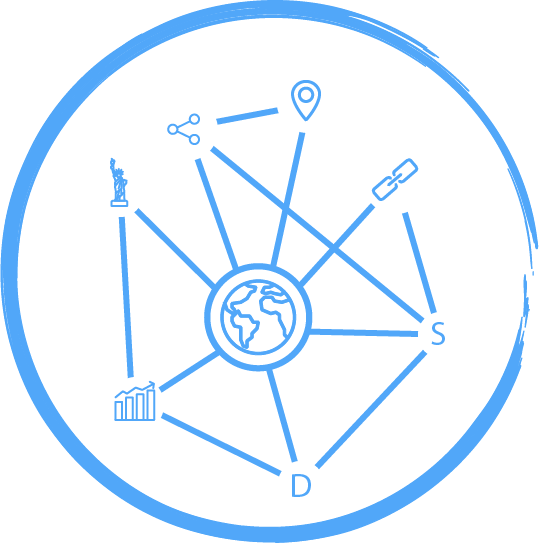


📷 Logo Analysis:
This logo shows a circular design with a globe or Earth at the center, from which multiple lines radiate outward like spokes of a wheel or rays of light. Around the perimeter of these radiating lines are various icons representing different concepts or services:

Key design elements include:
- A central globe/world icon symbolizing global reach or connectivity
- Radiating lines creating a hub-and-spoke pattern
- Various peripheral icons including:
  - A location/map pin
  - A sharing/network icon
  - What appears to be a chain link (possibly representing connections)
  - A chart/graph icon (likely representing analytics or data)
  - A figure that might represent a person or statue
  - Letters "S" and "D" visible on some spokes

The entire design is rendered in a blue color scheme and enclosed within a circular border. This type of logo design typically represents a company or service that offers multiple integrated solutions or services from a central platform, emphas

In [13]:
# Analyzing a local image using base64 encoding
# We'll use the logo from the data folder

from pathlib import Path

# Read and encode the local image
image_path = Path("../data/D4Sci_logo_ball.png")

if image_path.exists():
    with open(image_path, "rb") as f:
        image_data = base64.standard_b64encode(f.read()).decode("utf-8")
    
    # Display the image
    display(Image(filename=str(image_path), width=200))
    
    response = client.messages.create(
        model="claude-sonnet-4-20250514",
        max_tokens=300,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "source": {
                            "type": "base64",
                            "media_type": "image/png",
                            "data": image_data
                        }
                    },
                    {
                        "type": "text",
                        "text": "What is shown in this logo? Describe the design elements."
                    }
                ]
            }
        ]
    )
    
    print("\n📷 Logo Analysis:")
    print(response.content[0].text)
else:
    print(f"Image not found at {image_path}")


---
## 7. API Structure

Understanding the structure of API requests and responses is essential for effective usage.

### Request Components:
```python
client.messages.create(
    model="claude-sonnet-4-20250514",  # Model selection
    max_tokens=1024,                   # Maximum response length
    temperature=0.7,                   # Creativity control (optional)
    system="...",                      # System prompt (optional)
    messages=[                         # Conversation history
        {"role": "user", "content": "..."},
        {"role": "assistant", "content": "..."},
        ...
    ]
)
```

### Response Structure:
```python
response.id          # Unique response ID
response.type        # "message"
response.role        # "assistant"
response.content     # List of content blocks
response.model       # Model used
response.stop_reason # Why generation stopped
response.usage       # Token usage statistics
```


In [14]:
# Exploring the full response structure

response = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=100,
    system="You are a helpful assistant that responds concisely.",
    messages=[
        {"role": "user", "content": "What is Python?"}
    ]
)

print("📋 Full Response Object:")
print(f"  ID: {response.id}")
print(f"  Type: {response.type}")
print(f"  Role: {response.role}")
print(f"  Model: {response.model}")
print(f"  Stop Reason: {response.stop_reason}")
print()
print("📊 Token Usage:")
print(f"  Input tokens: {response.usage.input_tokens}")
print(f"  Output tokens: {response.usage.output_tokens}")
print()
print("💬 Content:")
for i, block in enumerate(response.content):
    print(f"  Block {i} (type={block.type}):")
    print(f"    {block.text}")


📋 Full Response Object:
  ID: msg_01FY18Cury5BWs4VxgPcuPsN
  Type: message
  Role: assistant
  Model: claude-sonnet-4-20250514
  Stop Reason: end_turn

📊 Token Usage:
  Input tokens: 22
  Output tokens: 82

💬 Content:
  Block 0 (type=text):
    Python is a high-level, interpreted programming language known for its simple, readable syntax and versatility. Created by Guido van Rossum in 1991, it's widely used for web development, data science, artificial intelligence, automation, and many other applications. Python emphasizes code readability and allows developers to express concepts in fewer lines of code compared to many other languages.


In [15]:
# Different stop reasons

# Stop reason: "end_turn" - Natural completion
response1 = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=500,
    messages=[{"role": "user", "content": "Say hello."}]
)
print(f"Natural completion - Stop reason: {response1.stop_reason}")

# Stop reason: "max_tokens" - Hit token limit
response2 = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=5,
    messages=[{"role": "user", "content": "Write a long story about dragons."}]
)
print(f"Token limit hit - Stop reason: {response2.stop_reason}")
print(f"  Truncated response: '{response2.content[0].text}'")


Natural completion - Stop reason: end_turn
Token limit hit - Stop reason: max_tokens
  Truncated response: '# The Last Song of'


In [16]:
# Streaming responses for better UX

print("Streaming response:")
print("-" * 40)

with client.messages.stream(
    model="claude-sonnet-4-20250514",
    max_tokens=200,
    messages=[{"role": "user", "content": "Write a short poem about the ocean."}]
) as stream:
    for text in stream.text_stream:
        print(text, end="", flush=True)

print("\n" + "-" * 40)
print("Stream complete!")


Streaming response:
----------------------------------------
**Endless Blue**

Waves whisper secrets to the shore,
Salt-kissed winds carry ancient lore,
Beneath the surface, mysteries deep—
Where leviathans dance and mermaids sleep.

The ocean breathes with rhythmic tide,
Its vast embrace stretches far and wide,
Forever changing, forever true,
An endless canvas of shifting blue.
----------------------------------------
Stream complete!


In [17]:
# Error handling best practices

def safe_api_call(prompt, max_tokens=100):
    """Make an API call with proper error handling."""
    try:
        response = client.messages.create(
            model="claude-sonnet-4-20250514",
            max_tokens=max_tokens,
            messages=[{"role": "user", "content": prompt}]
        )
        return response.content[0].text
    
    except anthropic.APIConnectionError:
        return "Error: Could not connect to API. Check your internet connection."
    
    except anthropic.RateLimitError:
        return "Error: Rate limit exceeded. Please wait and try again."
    
    except anthropic.APIStatusError as e:
        return f"Error: API returned status {e.status_code}: {e.message}"

# Test the safe API call
result = safe_api_call("What is 2 + 2?")
print(f"Result: {result}")


Result: 2 + 2 = 4


---
## Summary

In this segment, we covered:

1. **Basic Principles**: Generative AI creates new content based on learned patterns
2. **Transformers**: Self-attention mechanisms enable understanding of context
3. **LLMs**: Large models trained on vast data with emergent capabilities
4. **Temperature**: Controls randomness (0=deterministic, 1=creative)
5. **Hallucinations**: Models can generate plausible but false information
6. **Vision**: Claude can analyze images via URLs or base64
7. **API Structure**: Messages format, response objects, streaming, error handling

### Next Steps
In Segment 2, we'll dive deeper into using Claude models effectively with:
- System prompts and assistant prefilling
- Input formatting best practices
- Multi-turn conversations
- Document summarization
